В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

**Метод МНК**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
medical_df = pd.read_csv('medical-charges.csv') # замініть на ваш шлях до файлу
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [2]:
import numpy as np
X = non_smoker_df[['age']].values
y = non_smoker_df[['charges']].values

In [3]:
def normal_equations(X,y):
    """Computes the closed-form solution to linear regression"""
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

In [4]:
# Додаємо колонку одиничок аби задачи bias терм (константу в моделі регресії)
X_with_intercept = np.c_[np.ones((X.shape[0], 1)), X]

In [5]:
MNK_coefs = normal_equations(X_with_intercept, y)

In [6]:
MNK_coefs

array([[-2091.42055657],
       [  267.24891283]])

In [7]:
predictions_MNK = np.dot(X_with_intercept, MNK_coefs)
predictions_MNK[:3], y[:3]

(array([[2719.0598744 ],
        [5391.54900271],
        [6727.79356686]]),
 array([[ 1725.5523 ],
        [ 4449.462  ],
        [21984.47061]]))

In [8]:
from sklearn.metrics import  root_mean_squared_error # заміна mean_squared_error
rmse = root_mean_squared_error(y, predictions_MNK) 

In [9]:
print('MNK_coefs: ', MNK_coefs)
print('RMSE: ', rmse)

MNK_coefs:  [[-2091.42055657]
 [  267.24891283]]
RMSE:  4662.505766636395


In [10]:
np.mean(y), np.std(y), np.min(y)

(np.float64(8434.268297856204),
 np.float64(5990.9645302876115),
 np.float64(1121.8739))

**Full-Batch градієнтного спуску з numpy**

In [11]:
def full_batch_gradient_descent(X, y, lr=0.1, epochs=100):
    m, b = 0.0, 0.0  # Початкові параметри
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X[:, 0] + b
        error = y_pred - y[:, 0]
        errors.append(sum(error**2))
        m_gradient = (2/n) * np.dot(error, X[:, 0])
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

In [12]:
m, b, errors = full_batch_gradient_descent(X, y, lr=0.0001, epochs=1000)
predictions_fbgd = m * X[:, 0] + b

m, b

(np.float64(221.1045843794301), np.float64(-41.98126853149978))

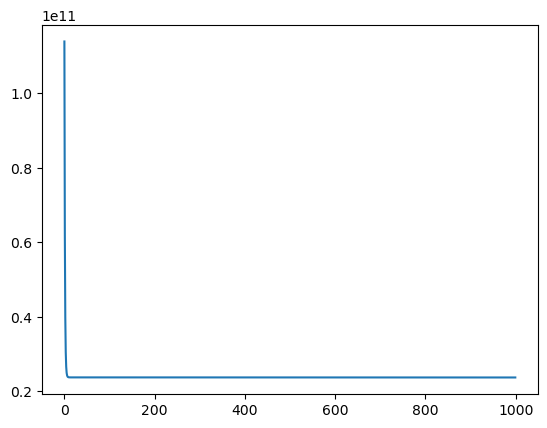

In [13]:
plt.plot(errors);

In [14]:
rmse_1 = root_mean_squared_error(y, predictions_fbgd) 
rmse_1

4713.250582815521

In [15]:
m2, b2, errors2 = full_batch_gradient_descent(X, y, lr=0.00001, epochs=1000)
predictions_fbgd2 = m * X[:, 0] + b

m2, b2

(np.float64(220.15455551129122), np.float64(0.21300652799863293))

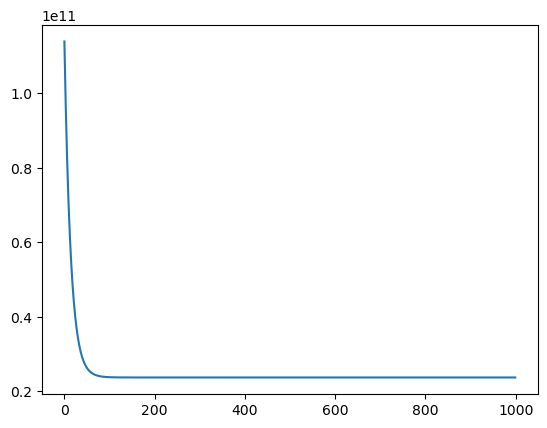

In [16]:
plt.plot(errors2);

In [17]:
rmse_2 = root_mean_squared_error(y, predictions_fbgd2) 
rmse_2

4713.250582815521

In [18]:
m3, b3, errors3 = full_batch_gradient_descent(X, y, lr=0.000001, epochs=1000)
predictions_fbgd3 = m * X[:, 0] + b

m3, b3

(np.float64(213.4575690658104), np.float64(4.33124916239435))

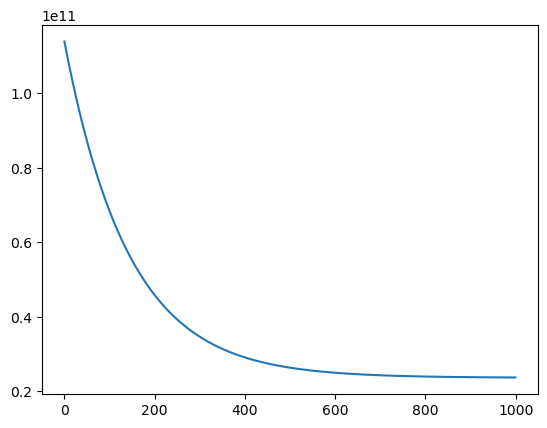

In [19]:
plt.plot(errors3);

In [20]:
rmse_3 = root_mean_squared_error(y, predictions_fbgd3) 
rmse_3

4713.250582815521

**scikit-learn.LinearRegression**

In [21]:
from sklearn.linear_model import LinearRegression

# Модель лінійної регресії засобами Scikit-learn (МНК)
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.coef_, lin_reg.intercept_

(array([[267.24891283]]), array([-2091.42055657]))

In [22]:
predictions_sklearn = lin_reg.predict(X)

In [23]:
rmse_sklearn = root_mean_squared_error(y, predictions_sklearn) 
rmse_sklearn

4662.505766636395

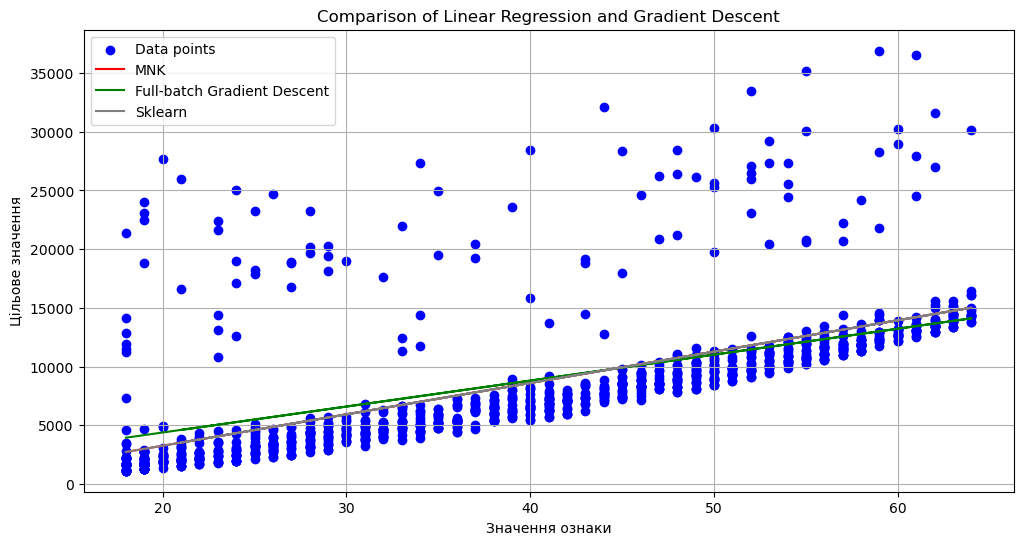

In [24]:
# Візуалізація результатів
plt.figure(figsize=(12, 6))
plt.scatter(X[:, 0], y, color='blue', label='Data points')
plt.plot(X[:, 0], predictions_MNK, color='red', label='MNK')
plt.plot(X[:, 0], predictions_fbgd, color='green', label='Full-batch Gradient Descent')
plt.plot(X[:, 0], predictions_sklearn, color='grey', label='Sklearn')
plt.title('Comparison of Linear Regression and Gradient Descent')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

Значення моделей MNK і SKlearn не відрізняються. Модель Full-batch трохи відрізняється і має більше значення помилки rmse.

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [25]:
smoker_df = medical_df[medical_df.smoker == 'yes']

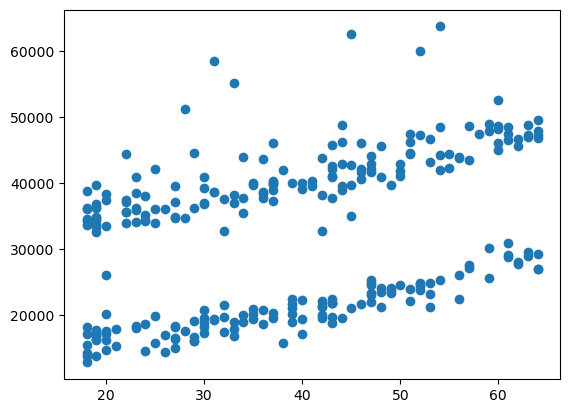

In [26]:
plt.scatter(smoker_df.age,smoker_df.charges);

In [27]:
X = smoker_df[['age']].values
y = smoker_df[['charges']].values

In [28]:
# Модель лінійної регресії засобами Scikit-learn (МНК)
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.coef_, lin_reg.intercept_

(array([[305.23760211]]), array([20294.12812692]))

In [29]:
predictions_sklearn = lin_reg.predict(X)

In [30]:
rmse_sklearn = root_mean_squared_error(y, predictions_sklearn) 
rmse_sklearn

10711.00334810241

In [31]:
np.mean(y), np.std(y), np.min(y)

(np.float64(32050.23183153284),
 np.float64(11520.46670652943),
 np.float64(12829.4551))

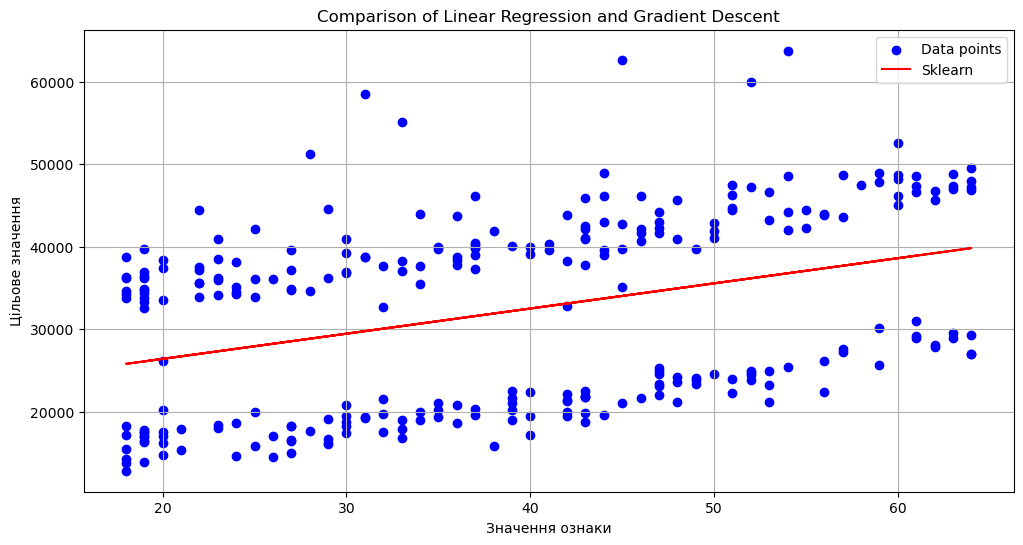

In [32]:
# Візуалізація результатів
plt.figure(figsize=(12, 6))
plt.scatter(X[:, 0], y, color='blue', label='Data points')
plt.plot(X[:, 0], predictions_sklearn, color='red', label='Sklearn')
plt.title('Comparison of Linear Regression and Gradient Descent')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

In [33]:
print('RMSE: ', rmse_sklearn)
print('std: ', np.std(y))
print('Коефіцієнти: ', lin_reg.coef_, lin_reg.intercept_)

RMSE:  10711.00334810241
std:  11520.46670652943
Коефіцієнти:  [[305.23760211]] [20294.12812692]


Значення RMSE завелика, близька до стандартного відхилення. Лінія регресії лягая погано. Модель не є дастатньо точною для практичного використання.